# Safety Analysis

## Install Libraries

In [2]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


## Import Libraries

In [5]:
import pandas as pd
import seaborn as sms
from matplotlib import pyplot as plt

## Read CSV File

In [6]:
df = pd.read_csv("IHMStefanini_industrial_safety_and_health_database.csv")
df

,Data,Countries,Local,Industry Sector,Accident Level,Potential Accident Level,Genre,Employee ou Terceiro,Risco Critico
0,2016-01-01 00:00:00,Country_01,Local_01,Mining,I,IV,Male,Third Party,Pressed
1,2016-01-02 00:00:00,Country_02,Local_02,Mining,I,IV,Male,Employee,Pressurized Systems
2,2016-01-06 00:00:00,Country_01,Local_03,Mining,I,III,Male,Third Party (Remote),Manual Tools
3,2016-01-08 00:00:00,Country_01,Local_04,Mining,I,I,Male,Third Party,Others
4,2016-01-10 00:00:00,Country_01,Local_04,Mining,IV,IV,Male,Third Party,Others
...,...,...,...,...,...,...,...,...,...
434,2017-07-04 00:00:00,Country_01,Local_04,Mining,I,III,Male,Third Party,Others
435,2017-07-04 00:00:00,Country_01,Local_03,Mining,I,II,Female,Employee,Others
436,2017-07-05 00:00:00,Country_02,Local_09,Metals,I,II,Male,Employee,Venomous Animals
437,2017-07-06 00:00:00,Country_02,Local_05,Metals,I,II,Male,Employee,Cut


## EDA and Data Visualization

### Basics

In [7]:
df.shape

(439, 9)

In [8]:
df.dtypes

Data                        object
Countries                   object
Local                       object
Industry Sector             object
Accident Level              object
Potential Accident Level    object
Genre                       object
Employee ou Terceiro        object
Risco Critico               object
dtype: object

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439 entries, 0 to 438
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Data                      439 non-null    object
 1   Countries                 439 non-null    object
 2   Local                     439 non-null    object
 3   Industry Sector           439 non-null    object
 4   Accident Level            439 non-null    object
 5   Potential Accident Level  439 non-null    object
 6   Genre                     439 non-null    object
 7   Employee ou Terceiro      439 non-null    object
 8   Risco Critico             439 non-null    object
dtypes: object(9)
memory usage: 31.0+ KB


In [10]:
df.isna().sum()

Data                        0
Countries                   0
Local                       0
Industry Sector             0
Accident Level              0
Potential Accident Level    0
Genre                       0
Employee ou Terceiro        0
Risco Critico               0
dtype: int64

In [11]:
df.describe()

,Data,Countries,Local,Industry Sector,Accident Level,Potential Accident Level,Genre,Employee ou Terceiro,Risco Critico
count,439,439,439,439,439,439,439,439,439
unique,287,3,12,3,5,6,2,3,34
top,2016-02-26 00:00:00,Country_01,Local_03,Mining,I,IV,Male,Third Party,Others
freq,13,263,90,241,328,155,417,189,232


In [12]:
df.duplicated().sum()


np.int64(23)

### Question 1: What is the frequency count of the different accident levels? 

In [13]:
df["Accident Level"].value_counts()

Accident Level
I      328
II      40
IV      31
III     31
V        9
Name: count, dtype: int64

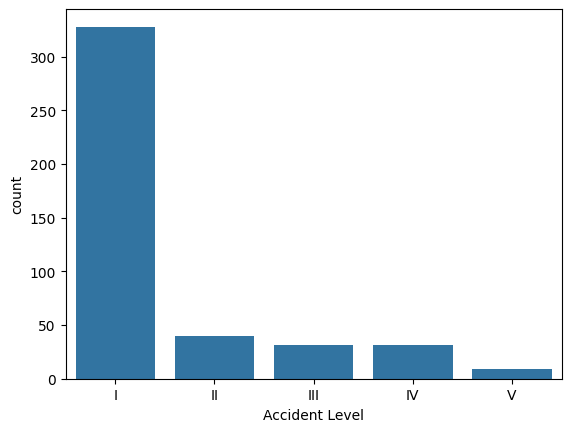

In [14]:
sms.countplot(x="Accident Level", data = df, order = ['I', 'II','III', 'IV', 'V'])
plt.show()

Note: The larger the roman numerals are, the more serious the issue is. This means most accidents are minor.

### Question 2: What is the frequency count of the potential accident levels? (Near Misses)

In [15]:
df["Potential Accident Level"].value_counts()

Potential Accident Level
IV     155
III    106
II      95
I       49
V       33
VI       1
Name: count, dtype: int64

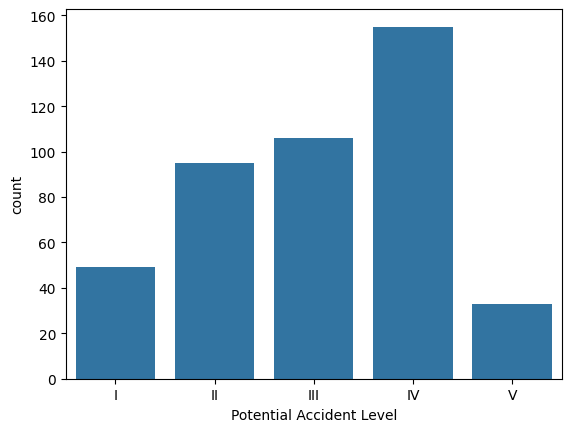

In [16]:
sms.countplot(x="Potential Accident Level", data = df, order = ['I', 'II','III', 'IV', 'V'])
plt.show()

Analysis: Here, we see a much different result compared to that of accident levels, showing that a lot of minor accidents could have became much worse.

Note: Potential Accident Level refers to severity of worst case scenario of incident and Accident Level refers to severity of what actualy took place

### Question 3: How distributed are the accident levels by country? (Numerically)

In [17]:
pd.crosstab(columns = df["Accident Level"], index = df["Countries"], margins = True, margins_name = 'Total')

Accident Level,I,II,III,IV,V,Total
Countries,,,,,,
Country_01,192,19,21,23,8,263
Country_02,99,19,7,6,1,132
Country_03,37,2,3,2,0,44
Total,328,40,31,31,9,439


In [18]:
pd.crosstab(columns = df["Potential Accident Level"], index = df["Countries"], margins = True, margins_name = 'Total')

Potential Accident Level,I,II,III,IV,V,VI,Total
Countries,,,,,,,
Country_01,10,51,64,115,22,1,263
Country_02,7,40,41,33,11,0,132
Country_03,32,4,1,7,0,0,44
Total,49,95,106,155,33,1,439


Analysis: Country_01 has the most amount of accidents out of all the other countries. However, this could be because more industry exists in that country, so we cannot say that the country is less safe

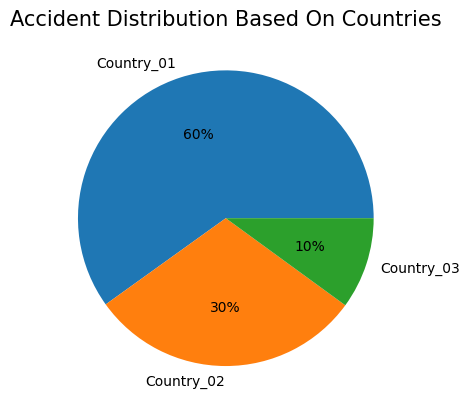

In [19]:
plt.title("Accident Distribution Based On Countries", size = 15)
plt.pie(x=df["Countries"].value_counts(), autopct="%1.0f%%", labels = ['Country_01','Country_02','Country_03'])
plt.show()

### Question 4: How distributed are the accident levels by Industry? (Numerically)

In [20]:
pd.crosstab(columns = df['Accident Level'], index = df["Industry Sector"],margins = True,margins_name = 'Total')

Accident Level,I,II,III,IV,V,Total
Industry Sector,,,,,,
Metals,119,12,7,8,2,148
Mining,167,26,20,21,7,241
Others,42,2,4,2,0,50
Total,328,40,31,31,9,439


In [21]:
pd.crosstab(columns = df['Potential Accident Level'], index = df["Industry Sector"],margins = True,margins_name = 'Total')

Potential Accident Level,I,II,III,IV,V,VI,Total
Industry Sector,,,,,,,
Metals,7,48,44,45,4,0,148
Mining,9,40,61,101,29,1,241
Others,33,7,1,9,0,0,50
Total,49,95,106,155,33,1,439


Mining has the most accidents compared to the other industry sectors.

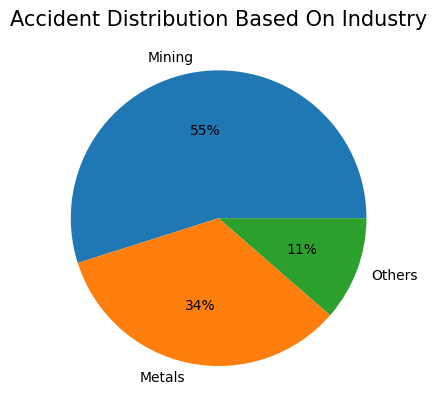

In [22]:
plt.title("Accident Distribution Based On Industry", size = 15)
plt.pie(x=df["Industry Sector"].value_counts(), autopct="%1.0f%%", labels = ['Mining','Metals','Others'])
plt.show()

### Question 5: How many males vs females get injuries

In [23]:
pd.crosstab(columns = df['Accident Level'], index = df["Genre"],margins = True,margins_name = 'Total')

Accident Level,I,II,III,IV,V,Total
Genre,,,,,,
Female,18,3,1,0,0,22
Male,310,37,30,31,9,417
Total,328,40,31,31,9,439


In [24]:
pd.crosstab(columns = df['Potential Accident Level'], index = df["Genre"],margins = True,margins_name = 'Total')

Potential Accident Level,I,II,III,IV,V,VI,Total
Genre,,,,,,,
Female,0,14,3,4,1,0,22
Male,49,81,103,151,32,1,417
Total,49,95,106,155,33,1,439


This above data shows that there are more injuries for males than females. This is probably due to the lack of female in the industry though.

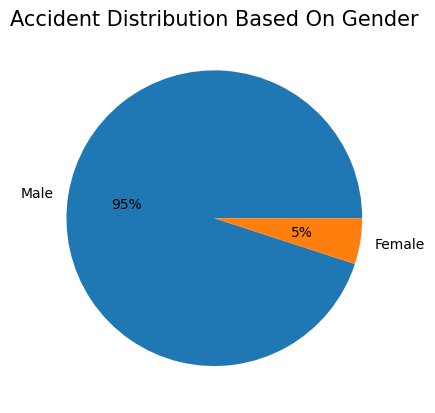

In [25]:
plt.title("Accident Distribution Based On Gender", size = 15)
plt.pie(x=df["Genre"].value_counts(), autopct="%1.0f%%", labels = ['Male','Female'])
plt.show()

### Question 6: What type of person gets injuries

In [26]:
pd.crosstab(columns = df['Accident Level'], index = df["Employee ou Terceiro"],margins = True,margins_name = 'Total')

Accident Level,I,II,III,IV,V,Total
Employee ou Terceiro,,,,,,
Employee,140,15,14,11,1,181
Third Party,134,19,14,16,6,189
Third Party (Remote),54,6,3,4,2,69
Total,328,40,31,31,9,439


In [27]:
pd.crosstab(columns = df['Potential Accident Level'], index = df["Employee ou Terceiro"], margins = True, margins_name = 'Total')

Potential Accident Level,I,II,III,IV,V,VI,Total
Employee ou Terceiro,,,,,,,
Employee,12,44,53,59,13,0,181
Third Party,32,37,35,69,15,1,189
Third Party (Remote),5,14,18,27,5,0,69
Total,49,95,106,155,33,1,439


Remote means outside of mines, such as a haul truck crashing into someone outside the mine. Third party means someone who doesn't work for the mine gets injured.

Analysis: Third party has a significant number of accidents, much more than expected (at least to the general public). It seems Third Party and Employee have an almost equal amounts of injuries

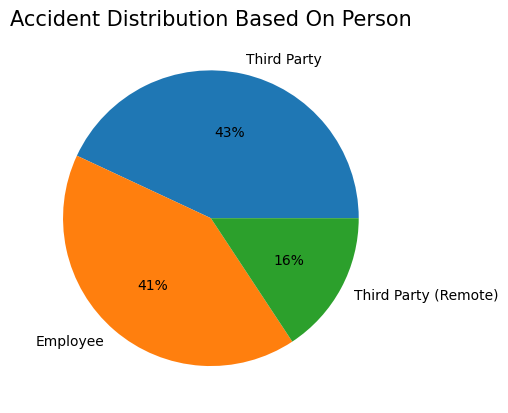

In [28]:
plt.title("Accident Distribution Based On Person", size = 15)
plt.pie(x=df["Employee ou Terceiro"].value_counts(), autopct="%1.0f%%", labels = ['Third Party','Employee', 'Third Party (Remote)'])
plt.show()

### Question 7: Distribution of injuries according to locality

In [29]:
pd.crosstab(columns = df['Accident Level'], index = [df["Local"], df['Countries']],margins = True,margins_name = 'Total')

,Accident Level,I,II,III,IV,V,Total
Local,Countries,,,,,,
Local_01,Country_01,46,1,5,4,1,57
Local_02,Country_02,15,6,2,1,0,24
Local_03,Country_01,66,8,5,8,3,90
Local_04,Country_01,31,9,7,6,3,56
Local_05,Country_02,51,6,2,0,0,59
Local_06,Country_01,48,1,3,5,1,58
Local_07,Country_02,9,2,1,2,0,14
Local_08,Country_02,19,5,1,3,1,29
Local_09,Country_02,1,0,1,0,0,2


Follows same trend as countries

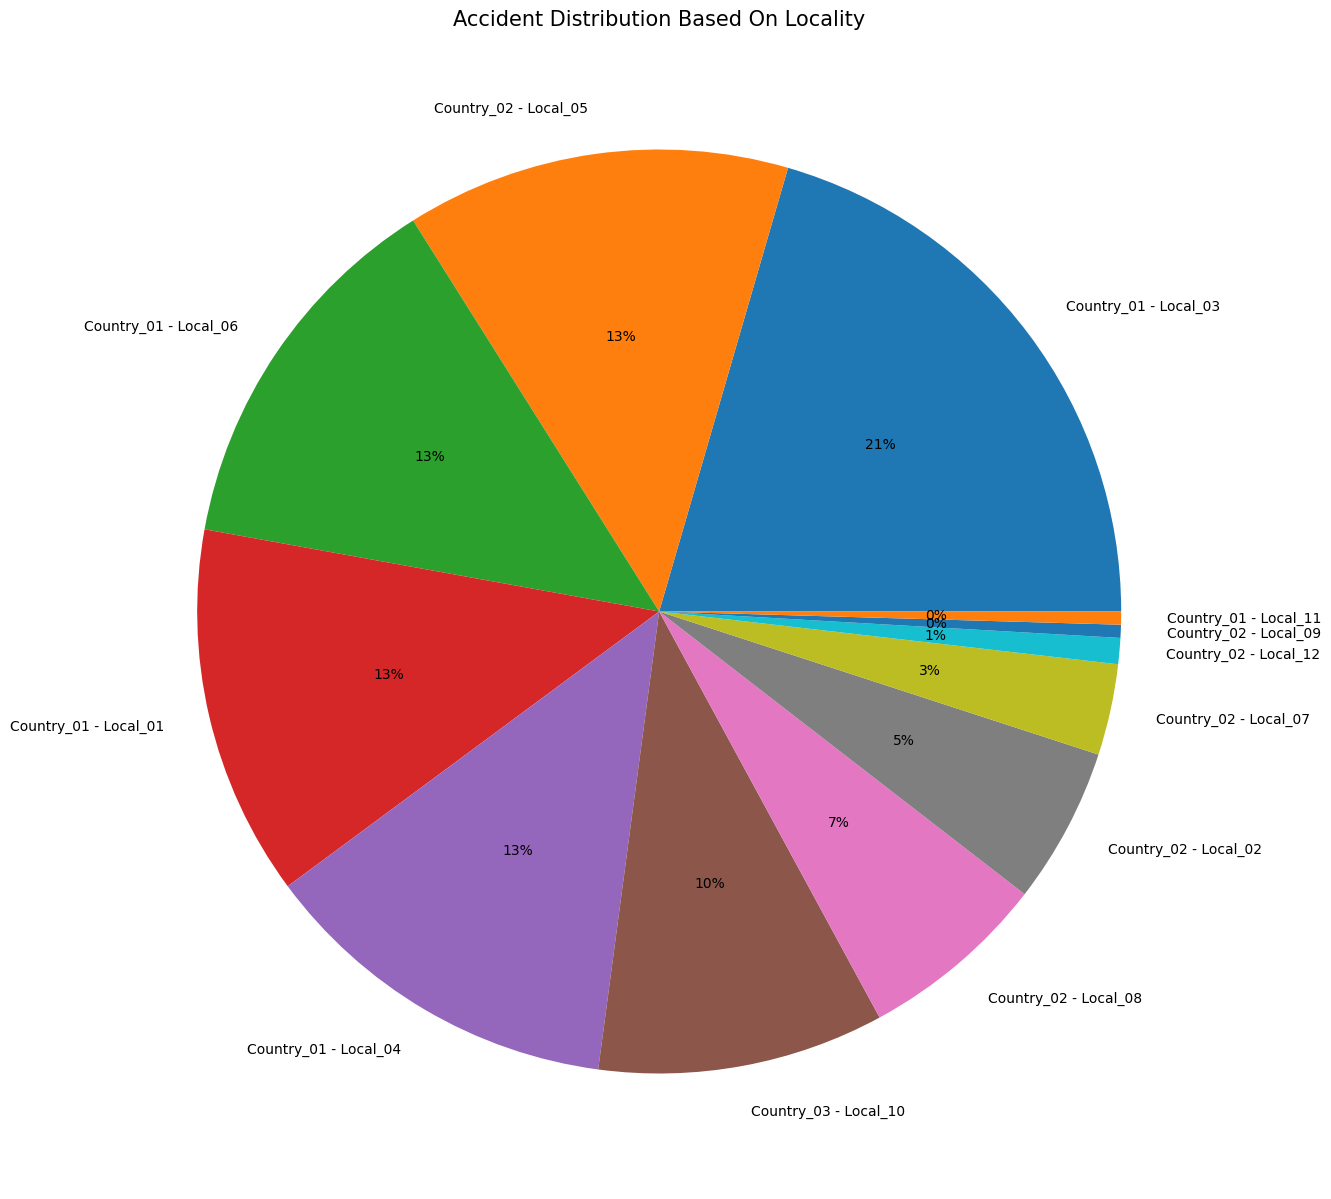

In [30]:
labels = (df["Countries"] + " - " + df["Local"]).value_counts().index
counts = (df["Countries"] + " - " + df["Local"]).value_counts()
plt.figure(figsize = (15, 15))
plt.title("Accident Distribution Based On Locality", size = 15)
plt.pie(x=counts, autopct="%1.0f%%", labels = labels)
plt.show()

### Question 8: what caused the injuries

In [31]:
pd.crosstab(columns = df['Accident Level'], index = df['Risco Critico'],margins = True,margins_name = 'Total')

Accident Level,I,II,III,IV,V,Total
Risco Critico,,,,,,
\nNot applicable,0,0,0,1,0,1
Bees,10,0,0,0,0,10
Blocking and isolation of energies,3,0,0,0,0,3
Burn,0,0,1,0,0,1
Chemical substances,15,2,0,0,0,17
Confined space,1,0,0,0,0,1
Cut,11,2,1,0,0,14
Electrical Shock,2,0,0,0,0,2
Electrical installation,0,0,0,1,0,1


In [32]:
df['Risco Critico'].nunique()

34

### Question 9: Average Accident Level

In [33]:
def convert_roman_numeral_to_int(x):
    if x == 'I':
        return 1
    elif x == 'II':
        return 2
    elif x == 'III':
        return 3
    elif x == 'IV':
        return 4
    elif x == 'V':
        return 5

In [34]:
df["Accident Level"].apply(convert_roman_numeral_to_int).mean()

np.float64(1.5261958997722096)

In [35]:
df["Potential Accident Level"].apply(convert_roman_numeral_to_int).mean()

np.float64(3.0639269406392695)

So on average, an actual accident is around 1/2 the severity of it's worst case scenatio

### Question 10: Standard Deviation of Accident Level

In [36]:
df["Accident Level"].apply(convert_roman_numeral_to_int).std()

np.float64(1.0308580758254577)

In [37]:
df["Potential Accident Level"].apply(convert_roman_numeral_to_int).std()

np.float64(1.1482850068222081)

In [38]:
actual = df["Accident Level"].apply(convert_roman_numeral_to_int)
potential = df["Potential Accident Level"].apply(convert_roman_numeral_to_int)

ratio = actual / potential

print(ratio.mean())
print(ratio.std())

0.5340182648401826
0.2772009447391633


The mean severity ratio is 0.534, indicating that, on average, actual accidents reached only 53.4% of their estimated potential severity. The standard deviation of 0.277 suggests moderate variability in this ratio, meaning that while actual accidents were generally about half as severe as their potential outcomes, the proportion differed noticeably across individual incidents.

### Question 11: Trend of Accident Level based on Time

In [39]:
pd.crosstab(columns = df['Accident Level'], index = df['Data'],margins = True,margins_name = 'Total')

Accident Level,I,II,III,IV,V,Total
Data,,,,,,
2016-01-01 00:00:00,1,0,0,0,0,1
2016-01-02 00:00:00,1,0,0,0,0,1
2016-01-06 00:00:00,1,0,0,0,0,1
2016-01-08 00:00:00,1,0,0,0,0,1
2016-01-10 00:00:00,0,0,0,1,0,1
...,...,...,...,...,...,...
2017-07-04 00:00:00,2,0,0,0,0,2
2017-07-05 00:00:00,1,0,0,0,0,1
2017-07-06 00:00:00,1,0,0,0,0,1


In [40]:
pd.crosstab(columns = df['Potential Accident Level'], index = df['Data'],margins = True,margins_name = 'Total')

Potential Accident Level,I,II,III,IV,V,VI,Total
Data,,,,,,,
2016-01-01 00:00:00,0,0,0,1,0,0,1
2016-01-02 00:00:00,0,0,0,1,0,0,1
2016-01-06 00:00:00,0,0,1,0,0,0,1
2016-01-08 00:00:00,1,0,0,0,0,0,1
2016-01-10 00:00:00,0,0,0,1,0,0,1
...,...,...,...,...,...,...,...
2017-07-04 00:00:00,0,1,1,0,0,0,2
2017-07-05 00:00:00,0,1,0,0,0,0,1
2017-07-06 00:00:00,0,1,0,0,0,0,1


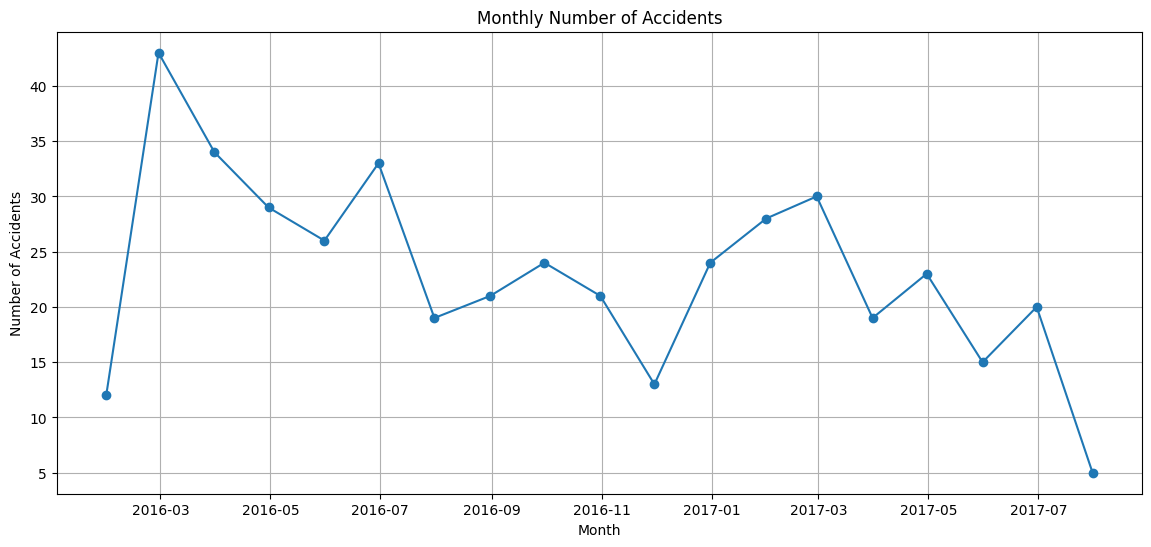

In [41]:
df["Data"] = pd.to_datetime(df["Data"])


monthly = df.set_index("Data").resample("ME").size()

plt.figure(figsize=(14,6))
plt.plot(monthly.index, monthly.values, marker='o')

plt.title("Monthly Number of Accidents")
plt.xlabel("Month")
plt.ylabel("Number of Accidents")
plt.grid(True)

plt.show()